# The prompt workbench

One afternoon, made by hand, one model call at a time: the script first, then the moments built out of it, then the afternoon walked step by step with the pages drawn and somebody standing in for the person.

**The prompts live in this notebook.** Step 1 imports the ones the product sends, and after that they are the notebook's own — edit them, and nothing in `agents/` moves until we copy a settled one back.

**The generation is split in two, and the product's is not.** `panel/devising.py` asks for the whole afternoon in one answer; here the script is settled and read before anything is staged out of it. That is a design being tried, not the one that runs.

Nothing here is screened, checked or repaired unless a cell says so. What comes back is what the model said.

In [1]:
import json
import os
import sys
import time
from pathlib import Path
from string import Template

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402 - the root has to be on the path first
from research.calls import a_context  # noqa: E402
from shared.ids import new_request_id  # noqa: E402
from shared.routing import Capability, ModelRequest  # noqa: E402
from shared.safety import ContentKind  # noqa: E402

bench.environment()
CTX = a_context(time.time())


async def say(prompt: str, *, most: int = 12000, why: str = "workbench") -> str:
    """One call with exactly this text. No checks, no safety gate, nothing repaired."""
    began = time.time()
    payload = await CTX.router.analyze(
        ModelRequest(
            capability=Capability.PLANNING,
            prompt=prompt,
            request_id=new_request_id(),
            max_output_chars=most,
            purpose=why,
            content_kind=ContentKind.EXERCISE_JSON,
        )
    )
    print(f"{time.time() - began:.1f} s · {len(payload.text)} characters back")
    return payload.text


def json_in(said: str) -> dict:
    start, end = said.find("{"), said.rfind("}")
    if start < 0 or end <= start:
        raise ValueError(f"no object in the answer: {said[:300]!r}")
    return json.loads(said[start : end + 1])

## 1. Import the prompts

Every block the deviser sends, with the format's own numbers filled in. The placeholders left as `$name` are the ones that carry a household's material.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")

task                         2077
format                       4935
shape-of-a-moment            2765
acts                         1099
marks-on-a-page              3466
ten-dimensions               1135
rules-head                     88
limits                        482
rules-tail                    713
asking                        376
manner-head                   391
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1399
worth-doing                  5117
manner-tail                   114
method                        810
household                    1391
pitch                         516
stand-in                     1535


In [3]:
print(P["task"])

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and

To work on one, print it as the line of Python that overrides it, and paste that into the cell below.

In [4]:
print(bench.to_paste("worth-doing", P["worth-doing"]))

P["worth-doing"] = r"""
What an afternoon is made of, and how much room there is to make it in:

**What you have to tell it in.** One printed sheet, or two if the afternoon really needs it, and about five displays of four short lines. That is everything. Not a summary of the afternoon — the afternoon. If the story you have in mind does not fit in that, it is the wrong story, and cutting it down will not save it: what arrives will be a synopsis of something good, which is worse than something small and whole.

**A display is gone when the next one comes. A sheet stays on the table.** Anything somebody has to use later — a name, a number, a rule, a list — belongs on the paper. A display can point, ask, react and close. It cannot carry a fact forward, and an afternoon that expects it to is one where somebody is asked to remember something they were shown for a minute an hour ago.

**Few things have names.** One person, one place, one object, one word, and a fifth if it earns it. Everythin

## 2. The notebook's own versions

Anything assigned here wins over what was imported. The two below do not exist in the repository at all: they are the shapes the two calls ask for.

In [5]:
# Leaner than what the repository sends, and that is the experiment: the imported
# blocks carry 117 prohibitions across 279 sentences, and a text written to satisfy
# them comes out in the shape of compliance. Keys that are not repository keys
# (brief, rules, voice) stand in for several of them at once.

P["brief"] = r"""
You are making one afternoon for one adolescent to spend at home, mostly alone, in a house with a printer, a scanner and a small screen or two. Not a lesson and not a test. One thing worth doing, that happens once and is over when it is over.

It works when four things are true.
  Somebody can start it alone: the first screen puts a situation in front of them and they can see what to pick up.
  Something is genuinely not known at the start and known at the end, and it is about a person, a decision, or something somebody wanted or was afraid of.
  Every step leaves a mark: written, drawn, cut, folded, counted, put in order.
  Something exists at the end that did not exist before, and it belongs to whoever made it.

You have one printed sheet, or two, and about five screens of four short lines. A screen is gone when the next one comes and the sheet stays on the table, so anything somebody needs later is on the paper.

Ask only what you have written the answer to. Not the letters inside a word, not arithmetic, not a date or a name that would have to be looked up. Everything else here can be walked away from; a question with no answer cannot.

Be strange before being clear. One impossible thing, plainly told, beats four ordinary ones tangled together. Pirates, escape rooms, quizzes, murder mysteries, the apocalypse and a computer gone mad are your first idea rather than your best one: take what you actually wanted from it and build that.

Few things have names - one person, one place, one object. Everything else is the letter, the box, the one underneath.

Write it for somebody of about fifteen who is interested in things and has never needed anybody to be pleased with them.
"""

P["format-script"] = r"""
Answer with JSON and nothing else:
{"title": "<text>", "overview": "<text>", "themes": ["..."], "minutes": <whole number>, "script": "<text>"}

  title: at most 60 characters.
  overview: at most 600 characters, for a parent glancing at it. What the person does, what comes off the printer, what is in their hands at the end, anything the house has to find, and the one thing somebody might not like about it. Not what it feels like to be inside it.
  themes: at most 5, at most 40 characters each. Nouns.
  minutes: 30 to 240. Pick what this game wants.
  script: at most 6000 characters, and use them. The game itself, written for whoever runs the afternoon, in these parts, each headed by its own name on its own line:
    THE WORLD. Where this is set, and two or three specifics that make it true.
    THE WAY IN. The thing in the room today that somebody picks up.
    THE QUESTION. What is not known, in one sentence. Then: the answer; the two or three things on the paper that settle it; the operation somebody does with them, named in a word; the false answer, and the thing already on the paper that makes it collapse; who wanted to know.
    THE BEATS. Six to twelve lines: what happens, and what it makes somebody do. Say which one turns it over and which one is where the answer arrives.
    WHAT IS MADE. Every object that comes off the printer, one line each: what it is inside the story, what it says, what it asks for. Name the thing and not the format - a shipping manifest, not a table. Each one is drawn whole, as a picture, from the description you give of it: say what the object is, never how it is laid out, and never a grid, a table or anything set in columns.
    WHAT IS HELD BACK. Two or three things, and what somebody has to do before each is given.
    WHERE IT CAN GO DIFFERENTLY. What happens if the paper comes back full, if it comes back untouched, and if somebody stops halfway.
"""

P["format-moments"] = r"""
Answer with JSON and nothing else:
{"drawn": { ... }, "moments": [ ... ]}

The title, the overview, the themes, the minutes and the script are settled and quoted below. Do not write them again and do not contradict them. Do not write an id, a format version or a list of what the house needs.

Stage the script. THE BEATS are the moments. WHAT IS MADE is the pages. WHAT IS HELD BACK decides the rungs of help. WHERE IT CAN GO DIFFERENTLY is what the outcomes are for. THE WAY IN is the first moment: it puts the object in front of somebody rather than announcing what the afternoon is called.
"""

P["shape-of-a-moment"] = r"""
Every moment carries these five keys, and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. Never shown to anybody, so write it in English even when the afternoon is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} - the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The three take different numbers of minutes, short fewest and about a third of standard; extended adds one optional step.
  "help": four rungs, each {"after_minutes": <whole number>, "lines": [...]}, with after_minutes rising. A nudge inside the story, then a concrete clue, then an almost explicit instruction, then the answer in full - as something the story gives, never a correction, and never "the answer is". The same words are used whether somebody asked for help or the time simply passed.
  "way_out": {"in_hand": "<an object they are holding>", "heading": "<text>", "lines": [...], "minutes": <whole number>} - how to reach the ending from exactly this moment. in_hand is a real thing the afternoon has already put on the table; name it in these lines and in a line of this moment or an earlier one, with the word the story already uses for it. It never says anything is being cut short.
"""

P["acts"] = r"""
A moment is one of these, and carries no key other than the five above and the ones shown here:
  {"act": "say", ...} - puts words on the display.
  {"act": "hand_over", ..., "page": {"kind": "...", "title": "<text>", "note": [ ... ], "spaces": [ ... ], "illustration": "<text>"}, "instead": [at most 4 lines of at most 44 characters]} - prints one page and leaves it where it can be picked up. instead is what the display says when there is no printer, so this moment still reaches the same point in the story with no paper at all; it is not an apology and it does not mention the printer.
  {"act": "collect", ..., "outcomes": [{"when": "marks", "then": "<a later moment id, or ask>"}, {"when": "blank", "then": "<a later moment id, or ask>"}], "if_no_page": "<a later moment id, or ask>"} - takes a page back and reads what was added to it. if_no_page is where the afternoon goes when nothing was printed at all.
  {"act": "close", ...} - ends the afternoon on the display, from wherever it got to.
"""

P["marks-on-a-page"] = r"""
A page is an object out of the story, and it is drawn whole from what you say it is. You never say where anything goes.
  "kind": one of "map", "dossier", "label", "notebook", "notice". Pick the one the afternoon is already about. A label carries at most one place to write and a notice carries none.
  "title": at most 48 characters, lettered large. It names the object and not the task: "Le nuvole del ventiquattro", never "Scheda di osservazione".
  "note": at most 4 lines of at most 72 characters, under the title, written from inside the story - what this object is, who it belonged to, what it is for. One of its lines makes plain what to do with the sheet, and it is still the object talking: "Il catasto chiede dove passava il muro", not "Scrivi qui dove passava il muro".
  "spaces": at most 8 places to write, each {"label": "<at most 40 characters>", "room": "a_line" | "some_lines" | "a_box"}. a_line is a few words, some_lines a sentence or two, a_box is for drawing in. Two or three are better than six. The label names what goes in the space, in the object's own words, and never spells out the alternatives: "Previsione", not "Previsione: tornare / non tornare" - the space is where somebody chooses. Whatever a label asks for is either already printed on this sheet or handed over in the last rung of help.
  "illustration": at most 600 characters, in English, saying what is drawn on the page. It is drawn as a picture and never lettered: no titles, no captions, no writing of any kind, and nothing that only makes sense once words are on it - no scale bar, no legend, no compass rose, no sign, no clock face, no labelled parts. Name shapes and not materials. Never draw somewhere in this house: you have not seen it.
Every word you put in title, note and label is lettered exactly as you write it, in the language of the afternoon. Nothing else is written on the page.
"""

P["ten-dimensions"] = r"""
Draw this afternoon along ten dimensions, and write down what you drew:
  "drawn": {"frame": "<a short phrase>", "role": "<a short phrase>", "mechanic": "<a short phrase>", "progress": "<a short phrase>", "paper": "<a short phrase>", "glass": "<a short phrase>", "displays": "<a short phrase>", "camera": "<a short phrase>", "tone": "<a short phrase>", "ending": "<a short phrase>"}
  frame, where and when it is set. role, what the person is inside it. mechanic, what they actually do. progress, how it moves from one moment to the next. paper, what the sheets are for. glass, what putting a sheet on the scanner is for. displays, what the screens are for. camera, what a photograph would be for or that there is none. tone, how it sounds. ending, what shape the ending has.
None of the ten is about the person, and there is nowhere to write anything about them.
"""

P["rules"] = r"""
Between 3 and 12 moments, and they run in the order you list them.
Before you answer, walk your own list and check it. Start at the first moment. After a say or a hand_over, go to the next moment you listed. At a collect, go only where its outcomes point. A close ends the afternoon. Every moment you wrote has to be reached on some walk, and every walk has to end at a close. Anything you list after a close is reached only if some outcome names it, so put the endings of the other branches last and name them.
An outcome leads to a moment later in your list, never backwards. A collect follows a hand_over. The last moment closes or collects, and at least one moment closes.
minutes is how long the afternoon lasts, between 30 and 240, and it is yours to choose. The longest way through your moments at their short weights has to fit inside it.
Use ask once, on the outcome for a page that came back with marks on it: that is the branch with something written to go on with, and it is written later, with the page in front of somebody. So do not write the moments for that branch at all - the beats after the collect are not yours to stage here. The outcome for a page that came back blank names a moment you wrote, and so does if_no_page, and both of those are endings. After the collect there are only those endings.
"""

P["voice"] = r"""
How the lines read:
  One instruction at a time, saying what to do, with what, and where the mark goes.
  Somebody is speaking who is also interested, never a teacher. A display that is only imperatives is a worksheet read aloud.
  Calm and unhurried, no exclamation marks. Nothing here can be failed, nothing is scored, and stopping halfway is an ordinary way to finish.
  Nothing says how much is left, what comes tomorrow, or that there will be another one.
  Nothing asks for speed, fine dexterity, strength, reading aloud, a phone, going outside, or something learnt at school.
  The plan never explains itself: no mention of difficulty, of adapting, of age, or of anything about the person.
  It begins in the middle of something, and it ends on the object in their hands.
"""

P["household"] = r"""
Write every word of it in $language.
This house can: $capabilities
Interests the parent wrote down, as a place to begin: $interests
Begin from one of them when one fits. You may go somewhere they do not name, but never towards the list below.
To keep away from: $avoid
Afternoons already offered here, so write a different one: $already
What is true in this house at the moment, written by the parent: $note
That is a circumstance and never the subject.
At most $sheets sheets on the table at one time. It is a ceiling and not a target, and a sheet that has gone back on the glass is no longer on the table.
Keep a line of text to about $words_per_line words.
"""

## 3. The household

The material the prompt quotes. Plain variables, changed in place.

In [6]:
from shared.capabilities import HouseCapability

LANGUAGE = "Italian"
INTERESTS = ["i treni", "le mappe vecchie"]
AVOID = ["i ragni"]
ALREADY = []
NOTE = ""
SHEETS = 2
WORDS_PER_LINE = 6
CAN = frozenset(
    {
        HouseCapability.PRINT_A4,
        HouseCapability.SCAN_A4,
        HouseCapability.SHOW_800X480_1BIT,
    }
)

MATERIAL = Template(P["household"]).substitute(
    language=LANGUAGE,
    capabilities=", ".join(sorted(str(one) for one in CAN)),
    interests=json.dumps(INTERESTS, ensure_ascii=False),
    avoid=json.dumps(AVOID, ensure_ascii=False),
    already=json.dumps(ALREADY, ensure_ascii=False),
    note=json.dumps(NOTE, ensure_ascii=False),
    sheets=SHEETS,
    words_per_line=WORDS_PER_LINE,
)
print(MATERIAL)


Write every word of it in Italian.
This house can: print_a4, scan_a4, show_800x480_1bit
Interests the parent wrote down, as a place to begin: ["i treni", "le mappe vecchie"]
Begin from one of them when one fits. You may go somewhere they do not name, but never towards the list below.
To keep away from: ["i ragni"]
Afternoons already offered here, so write a different one: []
What is true in this house at the moment, written by the parent: ""
That is a circumstance and never the subject.
At most 2 sheets on the table at one time. It is a ceiling and not a target, and a sheet that has gone back on the glass is no longer on the table.
Keep a line of text to about 6 words.



The craft: one form and one move out of `methods/`, filtered to what this house can run.

In [7]:
from shared.methods import draw, load, runnable

RUNNABLE = runnable(load(), capabilities=CAN)
FORM, MOVE = draw(RUNNABLE)
CRAFT = Template(P["method"]).substitute(form=FORM.written(), move=MOVE.written())

print(f"{len(RUNNABLE)} methods this house can run · {FORM.method_id} + {MOVE.method_id}\n")
print(CRAFT)

145 methods this house can run · the-ending-is-how-many-times-you-chose + wrong-attempts-kept-side-by-side

Here is one form, taken from a manual of methods that work on paper. It is the shape of the thing somebody does, and it carries what is hard to know: how one is built, which parts move and what changes when they are moved, where the work actually sits, and where it falls apart on a printed sheet.

let the ending be how many times you chose one way
Five either-or questions and six endings, where the ending is the count of one kind of answer instead of the path that was taken.
How one is built: Write five questions with two answers each, A or B, and six endings numbered by how many A's. Print the five, a row of five blanks, and a table sending 0 A to one paragraph, 1 A to the next, up to 5. That is eleven pieces of writing. The full tree of the same five choices is thirty-two endings and sixty-three paragraphs, of which one reading sees six: ninety per cent of what gets written is 

## 4. What the first call is sent

In [8]:
STAGE_ONE = "\n".join(
    [
        P["brief"],
        P["format-script"],
        CRAFT,
        MATERIAL,
        P["manner-tail"],
    ]
)
print(f"{len(STAGE_ONE)} characters\n")
print(STAGE_ONE)

10116 characters


You are making one afternoon for one adolescent to spend at home, mostly alone, in a house with a printer, a scanner and a small screen or two. Not a lesson and not a test. One thing worth doing, that happens once and is over when it is over.

It works when four things are true.
  Somebody can start it alone: the first screen puts a situation in front of them and they can see what to pick up.
  Something is genuinely not known at the start and known at the end, and it is about a person, a decision, or something somebody wanted or was afraid of.
  Every step leaves a mark: written, drawn, cut, folded, counted, put in order.
  Something exists at the end that did not exist before, and it belongs to whoever made it.

You have one printed sheet, or two, and about five screens of four short lines. A screen is gone when the next one comes and the sheet stays on the table, so anything somebody needs later is on the paper.

Ask only what you have written the answer to. Not t

## 5. Call one: the script

Measured at 40–90 s.

In [9]:
SAID = await say(STAGE_ONE, most=12000, why="the script")
FIRST = json_in(SAID)

print(FIRST["title"])
print()
print(FIRST["overview"])
print()
print(FIRST["themes"], "·", FIRST["minutes"], "min")

85.4 s · 6012 characters back
La stazione sotto la carta

Un’unica circolare ferroviaria, stampata fronte e retro, contiene una vecchia mappa, cinque biforcazioni e sei possibili intenzioni. Si segnano percorsi e tentativi, si scopre a chi Mara voleva affidare la stazione, poi si aggiunge una linea personale e si invia una scansione. Servono matita e scanner. Alla fine resta una mappa piegata, unica. Potrebbe non piacere l’invito a rappresentare una propria paura senza cancellare gli errori.

['treni', 'cartografia', 'intenzione', 'tracce', 'scelta'] · 75 min


In [10]:
print(FIRST["script"])

IL MONDO
La Stazione Sotto esiste sotto la carta. I treni vi arrivano come spazi bianchi sulle mappe. I suoi orologi indicano ore diverse, mentre i segnali funzionano soltanto proiettando ombre. Molto tempo fa Mara tracciò l’ultima linea e spedì una circolare incompleta al capostazione, che ancora non sa a chi fosse destinata.

LA VIA D’ENTRATA
Sul tavolo c’è la circolare ferroviaria, stampata fronte e retro, con una matita. Il primo schermo dice:

Un treno ha perso la stazione.
Il foglio sa dove.
Prendi foglio e matita.
Scrivi il primo tentativo.

LA DOMANDA
A chi voleva affidare la Stazione Sotto, Mara?

La risposta: a chi avesse ricostruito il suo percorso e poi aggiunto una linea propria. La stabiliscono le cinque note accanto alle biforcazioni, la regola che collega il numero di A alle sei voci e la voce numero 3. L’operazione è: conteggio. La falsa risposta è che Mara volesse cancellare o nascondere per sempre la stazione; crolla davanti alla frase già stampata: «Se l’hai trovata

## 6. What the second call is sent

The script above goes in as material, quoted.

In [11]:
STAGE_TWO = "\n".join(
    [
        P["format-moments"],
        P["shape-of-a-moment"],
        P["acts"],
        P["marks-on-a-page"],
        P["ten-dimensions"],
        P["rules"],
        P["limits"],
        P["voice"],
        MATERIAL,
        P["manner-tail"],
        "This is the afternoon that has been settled. Build its moments out of it:",
        json.dumps(FIRST, ensure_ascii=False, indent=2),
    ]
)
print(f"{len(STAGE_TWO)} characters\n")
print(STAGE_TWO)

15268 characters


Answer with JSON and nothing else:
{"drawn": { ... }, "moments": [ ... ]}

The title, the overview, the themes, the minutes and the script are settled and quoted below. Do not write them again and do not contradict them. Do not write an id, a format version or a list of what the house needs.

Stage the script. THE BEATS are the moments. WHAT IS MADE is the pages. WHAT IS HELD BACK decides the rungs of help. WHERE IT CAN GO DIFFERENTLY is what the outcomes are for. THE WAY IN is the first moment: it puts the object in front of somebody rather than announcing what the afternoon is called.


Every moment carries these five keys, and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. Never shown to anybody, so write it in English even when the afternoon is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} - the same moment at three costs, reaching the same point in th

## 7. Call two: the moments

Measured at 60–160 s. `experience_in` fills the three fields no model is asked for.

In [12]:
from agents.experience_deviser import experience_in
from shared.experience import ExperienceError

SAID_TWO = await say(STAGE_TWO, most=20000, why="the moments")
SECOND = json_in(SAID_TWO)
REFUSAL = ""
try:
    EXPERIENCE = experience_in(json.dumps({**FIRST, **SECOND}, ensure_ascii=False))
except ExperienceError as exc:
    EXPERIENCE, REFUSAL = None, str(exc)
    print("the format refused it:", REFUSAL)
else:
    for one in EXPERIENCE.moments:
        print(f"{one.id:26} {one.act:10} {one.heading}")

104.7 s · 11634 characters back
entry-sheet                hand_over  Un foglio già in viaggio
first-forks                say        Tre biforcazioni
last-forks                 say        Le ultime due
count-voice                say        La voce del conteggio
remaining-traces           say        Le tracce che restano
own-line                   say        Una linea propria
scan-circular              collect    Il vetro legge
blank-ending               close      La linea può aspettare
no-page-ending             close      La mappa sullo schermo


One repair, and only if the format refused it. This is what `panel/devising.py` does on its own and the workbench does not: a line two characters over is ordinary, and a refusal that keeps coming back is the thing to change a prompt about.

In [13]:
if REFUSAL:
    SAID_TWO = await say(
        "\n".join([P["repair"], REFUSAL, "", SAID_TWO]), most=20000, why="repairing"
    )
    SECOND = json_in(SAID_TWO)
    EXPERIENCE = experience_in(json.dumps({**FIRST, **SECOND}, ensure_ascii=False))
    for one in EXPERIENCE.moments:
        print(f"{one.id:26} {one.act:10} {one.heading}")
else:
    print("nothing to repair")

nothing to repair


What the checks say. They refuse; nothing here repairs.

In [14]:
from shared.experience_checks import check

print("; ".join(map(str, check(EXPERIENCE, recent=(), sheets_at_most=SHEETS))) or "no complaints")

no complaints


## 8. The walk

Run the four cells below in order, then run them again, until it is over. Each pass is one moment.

⚠️ `gpt-image-2` has capacity 2 in this region: two page calls within about 30 s answer 429. A page is 25–35 s and a few cents.

In [15]:
from IPython.display import Image, display

from agents.page_maker import PageMaker
from shared.experience import ASK, Collect, HandOver, Say, Weight

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT = ORDER[0]
MINUTES = 0
DISPLAYS: list[str] = []
SHEET = ""


def show(moment) -> None:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    global MINUTES, SHEET
    weighing = moment.at(WEIGHT)
    MINUTES += weighing.minutes
    print(f"[{moment.act}] {moment.heading}   ({weighing.minutes} min, {MINUTES} in)")
    for line in weighing.lines:
        print(f"   display: {line}")
        DISPLAYS.append(line)
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, HandOver):
        page = moment.page
        SHEET = "\n".join(
            [f"[{page.kind}] {page.title}", *page.note]
            + [f"- {one.label} ({one.room})" for one in page.spaces]
        )
        print(f"\n   page [{page.kind}] {page.title}")
        for line in page.note:
            print(f"     {line}")
        for space in page.spaces:
            print(f"     [ {space.label} — {space.room} ]")
        print(f"     drawing: {page.illustration}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")


def next_id(moment, came: str | None = None) -> str | None:
    """Where the afternoon goes after this. None is where it ends."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        goes = next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
        return None if goes == ASK else goes
    return None

**a.** Where we are.

In [16]:
M = BY_ID[AT]
show(M)

[hand_over] Un foglio già in viaggio   (12 min, 12 in)
   display: Un treno ha perso la stazione.
   display: Il foglio sa dove.
   display: Prendi foglio e matita.
   display: Scrivi il primo tentativo.
     after 2 min: Mara ha lasciato una domanda aperta.
     after 5 min: Il primo riquadro accoglie un'ipotesi.
     after 8 min: Completa: «Mara voleva affidarla…»
     after 11 min: Scrivi un nome o un tipo di persona nel riquadro Primo tentativo.

   page [map] La circolare della Stazione Sotto
     Circolare di Mara al capostazione: a chi affidare la Stazione Sotto?
     0 compagnia; 1 oblio; 2 solo per sé; 3 chi ricostruisce e aggiunge.
     4 ogni viaggiatore; 5 cancellazione. Se mi trovi, aggiungi una linea.
     Le mie cinque note scelgono: cerchia, ripassa, conta A, non cancellare.
     [ Primo tentativo — some_lines ]
     [ Secondo tentativo — some_lines ]
     [ Scelte, tratti e cinque lettere — a_box ]
     [ Terzo tentativo e numero di A — some_lines ]
     [ Frase decisi

**b.** The page, if this moment hands one over.

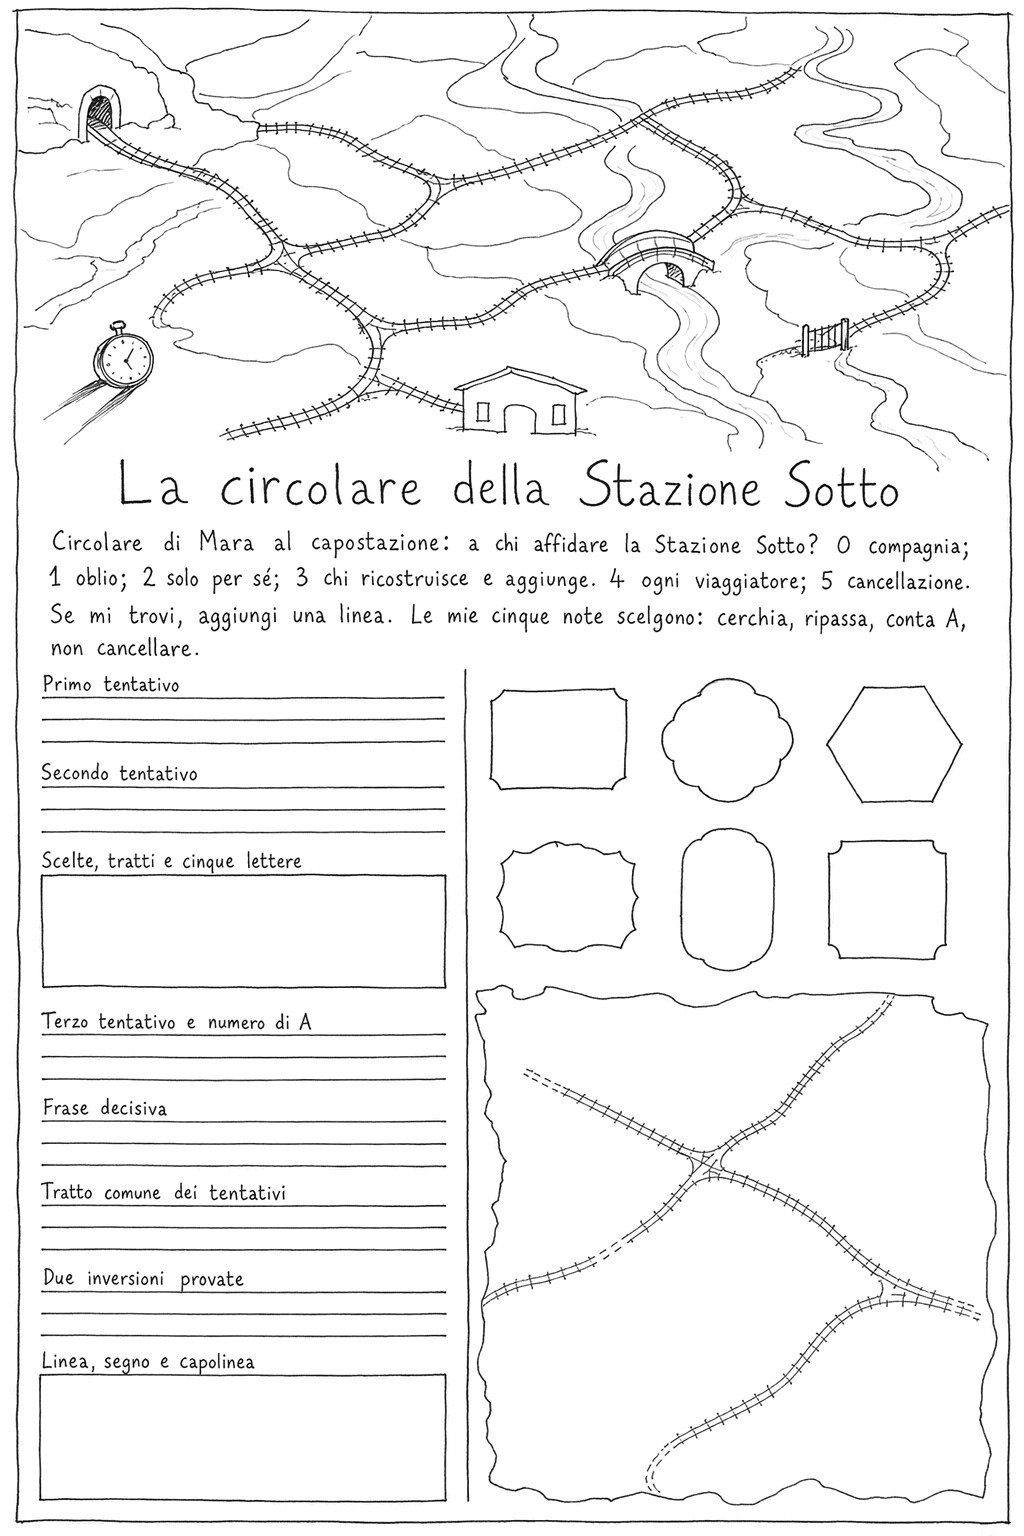

The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "La circolare della Stazione Sotto"
Letter this smaller, under the title: "Circolare di Mara al capostazione: a chi affidare la Stazione Sotto? 0 compagnia; 1 oblio; 2 solo per sé; 3 chi ricostruisce e aggiunge. 4 ogni viaggiatore; 5 cancellazione. Se mi trovi, aggiungi una linea. Le mie cinque note scelgono: cerchia, ripassa, conta A, non cancellare."
Leave three ruled lines, with "Primo tentativo" lettered above it
Leave three ruled lines, with "Secondo tentativo" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Scelte, tratti e cinque lettere" lettered above it
Leave three ruled lines, with "Terzo tentativo e numero di A" lettered above it
Leave three ruled lines, with "Frase decisiva" lettered above it
Leave three ruled lines, with "Tratto comune dei tentativi" lettered above

In [17]:
if isinstance(M, HandOver):
    PNG, ASKED = await PageMaker().draw(CTX, M.page)
    (ROOT / "tmp").mkdir(exist_ok=True)
    (ROOT / "tmp" / f"{M.id}.png").write_bytes(PNG)
    display(Image(PNG, width=520))
    print(ASKED)
else:
    print(f"{M.act} — nothing to draw here")

**c.** What the person did with it, if this moment collects one.

In [18]:
if isinstance(M, Collect):
    STANDING_IN = Template(P["stand-in"]).substitute(
        displays="\n".join(DISPLAYS), sheet=SHEET, mood=MOOD, minutes=MINUTES
    )
    print(STANDING_IN)
    DID = json_in(await say(STANDING_IN, most=1200, why="standing in"))
    CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
    print(f"\n{CAME} · {DID.get('onIt')} · stop: {DID.get('stop')}\n{DID.get('why')}")
else:
    CAME = None
    print(f"{M.act} — nobody is being asked for anything here")

hand_over — nobody is being asked for anything here


**d.** Take the branch, and go back to **a**.

In [19]:
AT = next_id(M, CAME if isinstance(M, Collect) else None)
print("over" if AT is None else f"next: {AT}  ({BY_ID[AT].act})")

next: first-forks  (say)


## 9. When a prompt is settled

Say so and the block gets copied back into its `.md`, the assembly in `agents/experience_deviser.py` follows if the shape changed, `python -m tools.prompts --write` renders `docs/prompts/`, and `python -m research.run` measures it against the eight axes.

Until then this notebook and the repository say different things, on purpose.